# Moon Trajectory Dataset – Showcase

This notebook demonstrates how to explore and visualize the moon trajectory dataset generated by the scraping pipeline.

The dataset contains **minute-resolution observations** of:

- Moon altitude  
- Moon azimuth  
- Moon illumination (moon phase)

Location: **Munich, Germany**

The scraper can collect data for arbitrary time ranges.  
The example dataset included in this repository covers a **three-month period** to keep the project lightweight and quick to run.

Data source: **US Naval Observatory Altitude/Azimuth calculator**.

## Dataset overview

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (relative path from the notebooks/ directory)
df = pd.read_csv("../data/processed/moon_dataset.csv")

df["datetime"] = pd.to_datetime(df["datetime"])

# Set datetime as the dataframe index for time-series operations
df = df.set_index("datetime")

# Downsample to hourly resolution to make plotting faster
df_hourly = df[["Altitude", "Azimuth"]].resample("h").mean()

df.head()

,Time,Altitude,Azimuth,Illumination
datetime,,,,
2026-03-01 00:00:00,00:00,56.1,222.9,0.92
2026-03-01 00:01:00,00:01,56.0,223.2,0.92
2026-03-01 00:02:00,00:02,55.9,223.6,0.92
2026-03-01 00:03:00,00:03,55.8,223.9,0.92
2026-03-01 00:04:00,00:04,55.7,224.3,0.92


In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 133920 entries, 2026-03-01 00:00:00 to 2026-06-01 23:59:00
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Time          79617 non-null  str    
 1   Altitude      79617 non-null  float64
 2   Azimuth       79617 non-null  float64
 3   Illumination  79617 non-null  float64
dtypes: float64(3), str(1)
memory usage: 5.1 MB


## Moon altitude over time

Shows the Moon’s altitude above the horizon over time (hourly averages).

Each peak corresponds to the Moon reaching its highest point in the sky during a given night.  
The varying peak heights reflect the Moon’s changing declination during its ~27-day orbital cycle.

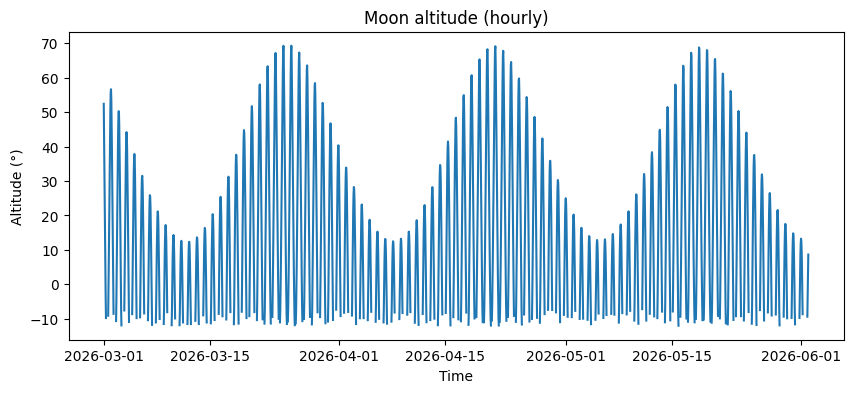

In [9]:
plt.figure(figsize=(10,4))
plt.plot(df_hourly.index, df_hourly["Altitude"])

plt.xlabel("Time")
plt.ylabel("Altitude (°)")
plt.title("Moon altitude (hourly)")

plt.show()

## Moon trajectory in the sky:

Left = East
Right = West

Each arc shows the Moon's path across the sky during a single night.
The varying arc heights reflect the Moon’s changing declination during
its ~27-day orbital cycle.

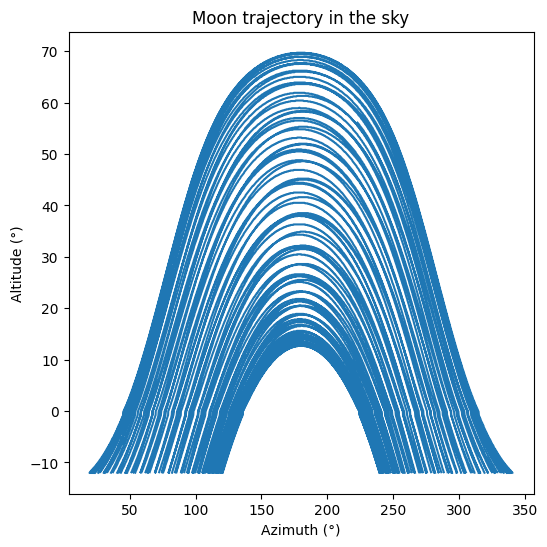

In [5]:
plt.figure(figsize=(6,6))

plt.plot(df["Azimuth"], df["Altitude"])

plt.xlabel("Azimuth (°)")
plt.ylabel("Altitude (°)")

plt.title("Moon trajectory in the sky")

plt.show()

## Moon phase cycle (fraction illuminated)

Shows the waxing and waning of the Moon by plotting the fraction of the lunar disk illuminated over time.  
The repeating pattern reflects the lunar synodic period (~29.5 days).

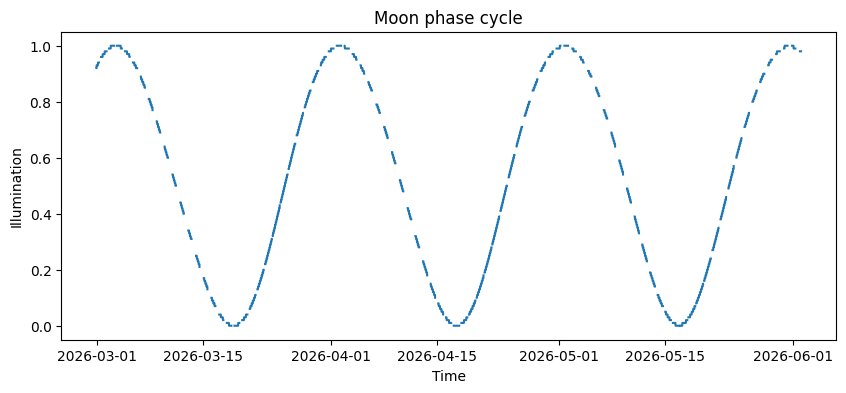

In [6]:
plt.figure(figsize=(10,4))

plt.plot(df.index, df["Illumination"])

plt.xlabel("Time")
plt.ylabel("Illumination")

plt.title("Moon phase cycle")

plt.show()